# 3.0 Data Distributions
---
---
I am going to do everything in this notebook and then split it up into more relevant notebooks since I want:
- Foundation, make the customer dataset
- 4 Firmographic, make country regions
- 1 Lifecycle / Value, basic RFM
- 2 Behavioural, shopping patterns --> persona backbone
- 3 Product Affinity, what can I get from the descriptions
- Triangulation, determine suitable personas from 1 - 4 and define business value
- Validation and testing and look for business relevant storyline

Once I see how all the above sits I can edit the portfolio appropriately

# Table Specifications
---
---

#### **Table name:** cleansed_retail_orders
- Fields: 15
- Rows: 1.067,371
- File Size: 9.5MB
- Approximate Memory Use: 256 MB

| **Field** | **Description** | **Data Type** | **Data Type Description** | **Example** |
| :--- | :--- | :--- | :--- | :--- |
| Invoice | This is the invoice number | Str | Number or C+Number for cancellations | 516171 |
| StockCode | This is the product code| Str | Number and additional admin/ops type letters | 22487 |
| Description | Full product description | Str | String of concatenated key words | PLASTERS IN TIN SPACEBOY |
| Quantity | number of products measure | Int 64 | There are negative numbers here for adjustments | 3 |
| InvoiceDate | Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| UnitPrice | Price of one line item | Float 64 | These are Pound Sterling and all positive | 0.39 |
| TotalPrice | Total price of lines items | Float 64 | This is Quantity x UnitPrice in Pound Sterling | 1.17 |
| CustomerHashID | Pseudonymised customer number | Str | Simulated hash using HMAC-SHA256 | 09c72970956ea... |
| Country | Full country names | Str | Country names including regions/unspecified | UNITED KINGDOM |
| Cancellation | Flag for line item changes | Bool | This is a True/False flag | False |
| InvoiceDateMin | Remove system timing issue from Date of Purchase / order | Datetime 64[us] | This is datetime YYYY-MM-DD hh:mm:ss form| 2011-11-21 12:06:00 |
| StockCodeType | Name of what it is, if not a stock code | Str | This is a string | Postage |
| DescriptionType | Summary of what it is, if not a stock code description | Str | This is a string | Damages |
| WarehouseInventory | These are warehouse stock control | Str | This is a string | Add Stock |
| CancellationType | More detail into what the cancellation is | Str | This is a string | Full Invoice Re-Key |
| OrderCheckout | Who raised the order | Str | This is a string | Customer Account |

---
# Load Data
---
---
First we need to load the data ready for Plotting Graphs:

In [1]:
import pandas as pd
import os

# Define the input path for the raw data
interim_parquet_path = "../data/interim/cleansed_online_retail_orders.parquet"
interim_dir = os.path.dirname(interim_parquet_path)

# 1. Check if the required directory structure exists
if not os.path.exists(interim_dir):
    print(f"❌ ERROR: The directory '{interim_dir}' does not exist.")
    print("Action Required - Please set up your local environment:")
    print("  1. Create the standard data folders: 'data/raw/', 'data/interim/', and 'data/processed/'.")
    print("  2. Ensure 'data/' is added to your .gitignore file.")
    print("Once complete, run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 2. If directory exists, check if the file already exists
elif not os.path.exists(interim_parquet_path):
    print(f"❌ ERROR: The file '{interim_parquet_path}' does not exist.")
    print("Action Required - Please run the entire ETL notebook 1_data_clean_and_stage.")
    print("Then rerun this cell.")

# 3. If file exists, load to dataframe
else:
    print("⏳ Importing df_cleansed_online_retail_orders ..")
    df_cleansed_online_retail_orders = pd.read_parquet(interim_parquet_path)
    print("✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.")

⏳ Importing df_cleansed_online_retail_orders ..
✅ Data loaded to dataframe df_cleansed_online_retail_orders complete.


---
---
# Distribution Analysis

In [2]:
# How do we identify B2B versus B2C customers in this dataset?
# Since we need to profile both customer groups differently before doing further analysis

# Rules for clean data filter to then get representative B2B and B2C customer profiles:
#  StockCodeType	= PRODUCT
#  DescriptionType  = PRODUCT
#  CancellationType = NaN
#  OrderCheckout    = CUSTOMER ACCOUNT
#  Gives 801,095 out of 1,067,371 -> 75% base for customer profile

# ========================================
# first we collapse data to customer level
# ========================================

import pandas as pd
import numpy as np

# Apply your B2B/B2C-base filter rules
mask = (
    (df_cleansed_online_retail_orders['StockCodeType']    == 'PRODUCT') &
    (df_cleansed_online_retail_orders['DescriptionType']  == 'PRODUCT') &
    (df_cleansed_online_retail_orders['CancellationType'].isna()) &
    (df_cleansed_online_retail_orders['OrderCheckout']    == 'CUSTOMER ACCOUNT')
)
df = df_cleansed_online_retail_orders.loc[mask].dropna(subset=['CustomerHashID']).copy()

# Per-invoice breadth (distinct SKUs in a basket)
inv_breadth = (df.groupby(['CustomerHashID','Invoice'])['StockCode']
                 .nunique().reset_index(name='breadth'))
inv_value   = (df.groupby(['CustomerHashID','Invoice'])['TotalPrice']
                 .sum().reset_index(name='basket_value'))
inv_qty     = (df.groupby(['CustomerHashID','Invoice'])['Quantity']
                 .sum().reset_index(name='basket_qty'))

# Customer-level aggregations
customer = df.groupby('CustomerHashID').agg(
    n_invoices         = ('Invoice',      'nunique'),
    n_lines            = ('Invoice',      'size'),
    n_skus             = ('StockCode',    'nunique'),
    total_qty          = ('Quantity',     'sum'),
    total_revenue      = ('TotalPrice',   'sum'),
    avg_qty_per_line   = ('Quantity',     'mean'),
    median_qty_per_line= ('Quantity',     'median'),
    max_qty_per_line   = ('Quantity',     'max'),
    avg_unit_price     = ('UnitPrice',    'mean'),
    first_purchase     = ('InvoiceDateMin','min'),
    last_purchase      = ('InvoiceDateMin','max'),
    n_countries        = ('Country',      'nunique'),
).reset_index()

customer = (customer
    .merge(inv_breadth.groupby('CustomerHashID')['breadth'].mean()
                       .rename('avg_basket_breadth'), on='CustomerHashID')
    .merge(inv_value.groupby('CustomerHashID')['basket_value'].mean()
                     .rename('avg_basket_value'), on='CustomerHashID')
    .merge(inv_qty.groupby('CustomerHashID')['basket_qty'].mean()
                   .rename('avg_basket_qty'), on='CustomerHashID')
)

# we don't know tenure so we use active span for the trading window
customer['active_span_days'] = (customer['last_purchase'] - customer['first_purchase']).dt.days.clip(lower=1)
customer['orders_per_month'] = customer['n_invoices'] / (customer['active_span_days'] / 30.44)
customer['recency_days']     = (df['InvoiceDateMin'].max() - customer['last_purchase']).dt.days
customer['repeat_customer']  = customer['n_invoices'] > 1
customer['cohort'] = customer['first_purchase'].dt.to_period('M')

# we flag customers first purchase within 30 days of window as left-censored since we don'k know when they actually started
data_start = df['InvoiceDateMin'].min()
buffer = pd.Timedelta(days=30)
customer['is_left_censored'] = customer['first_purchase'] <= (data_start + buffer)
# we add a cohort month for analysis that requires customer age
customer['cohort_month'] = customer['first_purchase'].dt.to_period('M')

print(customer.shape)
customer.head()

(5849, 23)


,CustomerHashID,n_invoices,n_lines,n_skus,total_qty,total_revenue,avg_qty_per_line,median_qty_per_line,max_qty_per_line,avg_unit_price,...,avg_basket_breadth,avg_basket_value,avg_basket_qty,active_span_days,orders_per_month,recency_days,repeat_customer,cohort,is_left_censored,cohort_month
0,00189f7baec2462e442b86d14102254df902adc5accc25...,11,189,172,2165,3349.57,11.455026,12.0,48,2.512487,...,17.181818,304.506364,196.818182,194,1.725979,10,True,2011-05,False,2011-05
1,002403301211297ae25ec229d6751c749330628e52940b...,9,115,30,1955,4049.79,17.000000,16.0,40,2.436696,...,12.777778,449.976667,217.222222,559,0.490089,108,True,2010-02,False,2010-02
2,0029315aefcd3710655f212f0d3b621343af84f1cf7aee...,4,9,3,162,420.30,18.000000,24.0,24,2.683333,...,2.250000,105.075000,40.500000,265,0.459472,9,True,2011-03,False,2011-03
3,0036e0e29c92201fb64bfb29e763cb17c5aa2b05f2e72b...,6,12,7,1233,1133.25,102.750000,50.0,200,1.500000,...,2.000000,188.875000,205.500000,143,1.277203,6,True,2011-07,False,2011-07
4,00386273912716004a52cf88eca0d3db7fb54734d0601f...,1,45,45,386,1693.88,8.577778,8.0,24,5.387556,...,45.000000,1693.880000,386.000000,1,30.440000,316,False,2011-01,False,2011-01


---
---
## First let's quantify B2B versus B2C customer profile

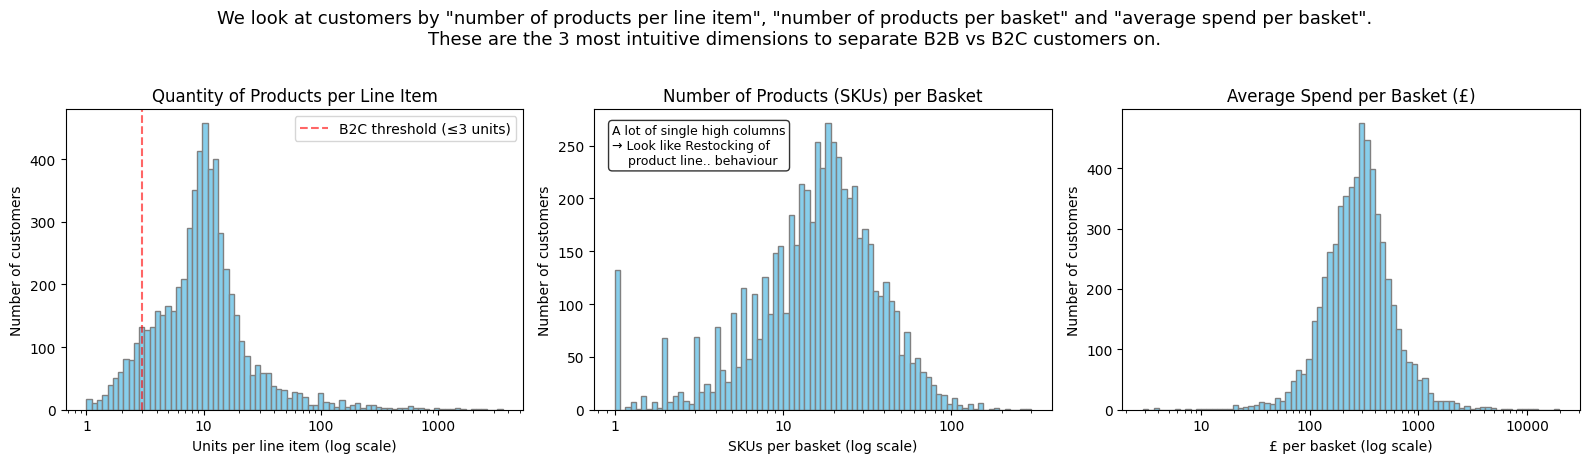

In [3]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

bins      = 80          # fewer bins on a log scale reads cleaner
color     = 'skyblue'
edgecolor = 'grey'

fig, ax = plt.subplots(1, 3, figsize=(16, 4.5))
fig.suptitle('We look at customers by "number of products per line item", "number of products per basket" and "average spend per basket".\nThese are the 3 most intuitive dimensions to separate B2B vs B2C customers on.',
             fontsize=13, y=1.02)

# ── Plot 1: Avg quantity per line ─────────────────────────────────────────
# Use log-spaced bins so the histogram is evenly distributed on a log axis
qty   = customer['avg_qty_per_line'].clip(lower=0.5)
edges = np.logspace(np.log10(qty.min()), np.log10(qty.max()), bins)

ax[0].hist(qty, bins=edges, color=color, edgecolor=edgecolor)
ax[0].set_xscale('log')
ax[0].set_title('Quantity of Products per Line Item')
ax[0].set_xlabel('Units per line item (log scale)')
ax[0].set_ylabel('Number of customers')
ax[0].xaxis.set_major_formatter(mticker.ScalarFormatter())  # show 1, 10, 100 not 10^0

ax[0].axvline(3, color='red', ls='--', alpha=0.6,
              label='B2C threshold (≤3 units)')
ax[0].legend()


# ── Plot 2: Avg basket breadth ────────────────────────────────────────────
brd   = customer['avg_basket_breadth'].clip(lower=0.5)
edges = np.logspace(np.log10(brd.min()), np.log10(brd.max()), bins)

ax[1].hist(brd, bins=edges, color=color, edgecolor=edgecolor)
ax[1].set_xscale('log')
ax[1].set_title('Number of Products (SKUs) per Basket')
ax[1].set_xlabel('SKUs per basket (log scale)')
ax[1].set_ylabel('Number of customers')
ax[1].xaxis.set_major_formatter(mticker.ScalarFormatter())

ax[1].text(0.04, 0.95, 'A lot of single high columns\n→ Look like Restocking of\n    product line.. behaviour',
           transform=ax[1].transAxes, va='top', fontsize=9,
           bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))


# ── Plot 3: Avg basket value ──────────────────────────────────────────────
val   = customer['avg_basket_value'].clip(lower=1)
edges = np.logspace(np.log10(val.min()), np.log10(val.max()), bins)

ax[2].hist(val, bins=edges, color=color, edgecolor=edgecolor)
ax[2].set_xscale('log')
ax[2].set_title('Average Spend per Basket (£)')
ax[2].set_xlabel('£ per basket (log scale)')
ax[2].set_ylabel('Number of customers')
ax[2].xaxis.set_major_formatter(mticker.ScalarFormatter())


plt.tight_layout()
plt.show()

---
There is nothing obvious in the above to suggest B2C customers ..
- Let's plot item quantity versus basket breadth to see if there is any significant B2C concentration in the bottom left corner

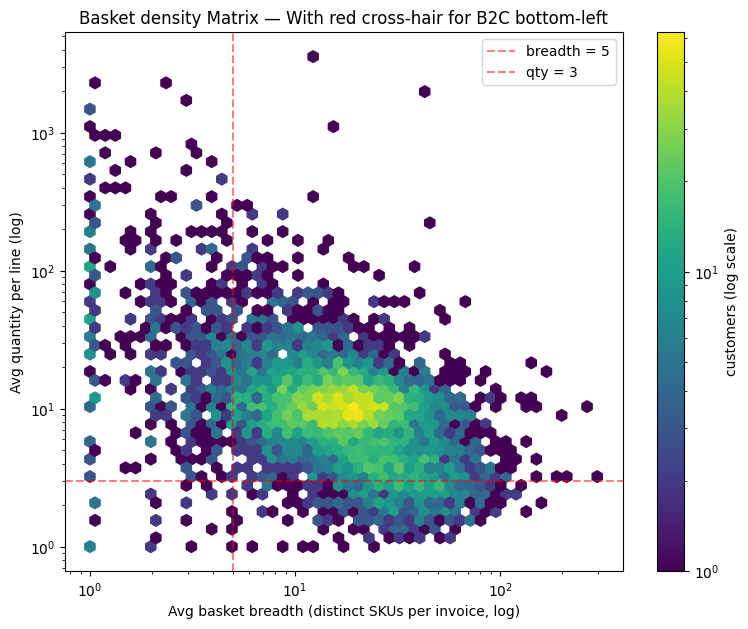

In [4]:
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LogNorm

x = customer['avg_basket_breadth'].clip(lower=0.5)
y = customer['avg_qty_per_line'].clip(lower=0.5)

fig, ax = plt.subplots(figsize=(9,7))
hb = ax.hexbin(x, y, gridsize=50, xscale='log', yscale='log',
               norm=LogNorm(), cmap='viridis', mincnt=1)
ax.set_xlabel('Avg basket breadth (distinct SKUs per invoice, log)')
ax.set_ylabel('Avg quantity per line (log)')
ax.set_title('Basket density Matrix — With red cross-hair for B2C bottom-left')
plt.colorbar(hb, ax=ax, label='customers (log scale)')

# Reference lines for a "B2C-like" zone
ax.axvline(5, color='red', ls='--', alpha=0.5, label='breadth = 5')
ax.axhline(3, color='red', ls='--', alpha=0.5, label='qty = 3')
ax.legend()
plt.show()

Those 4 graphs suggest this company is B2B only. 
- Even the 10^0 cluster far left is a vertical line going high on quantity suggesting stock replenishment for one or several products.

---
# Check for B2C specifically

In [5]:
b2c_candidates = customer[
    (customer['avg_qty_per_line']   <= 2)   &
    (customer['avg_basket_breadth'] >= 3)   &
    (customer['avg_basket_breadth'] <= 25)  &
    (customer['avg_basket_value']   <= 50)  &
    (customer['n_invoices']         <= 2)
].copy()

print(f"B2C-likeliest candidates: {len(b2c_candidates)} of {len(customer)} "
      f"({len(b2c_candidates)/len(customer):.1%})")

if len(b2c_candidates):
    cand_tx = df[df['CustomerHashID'].isin(b2c_candidates['CustomerHashID'])]
    print("\nTop products they buy:")
    print(cand_tx.groupby('Description').size()
                  .sort_values(ascending=False).head(20))
    print("\nCountry mix (by customer):")
    print("\nMedian profile:")
    print(b2c_candidates[['avg_basket_breadth','avg_qty_per_line',
                          'avg_basket_value','total_revenue']].median().round(2))

B2C-likeliest candidates: 6 of 5849 (0.1%)

Top products they buy:
Description
CHILLI LIGHTS                         2
AIRLINE BAG VINTAGE WORLD CHAMPION    1
RAIN PONCHO                           1
TEA TIME PARTY BUNTING                1
TABLECLOTH RED APPLES DESIGN          1
SWEETHEART 3 TIER CAKE STAND          1
SET OF 3 BLACK FLYING DUCKS           1
SEASIDE FLYING DISC                   1
SAVOY ART DECO CLOCK                  1
S 4 GROOVY CAT MAGNETS                1
ROSE DU SUD WASHBAG                   1
REX CASH CARRY JUMBO SHOPPER          1
RED WHITE DOTS RUFFLED UMBRELLA       1
RED SPOTTY WASHBAG                    1
RED HEARTS LIGHT CHAIN                1
RAIN PONCHO RETROSPOT                 1
PINK KNITTED COW STUFFED TOY          1
ALARM CLOCK BAKELIKE GREEN            1
PINK JUMPER LARRY THE LAMB            1
PARTY BUNTING                         1
dtype: int64

Country mix (by customer):

Median profile:
avg_basket_breadth     5.00
avg_qty_per_line       1.20
avg_bas

---
---
# We add more useful fields for analysis downstream

---
## Percentage case packs
 We add pack_size, is_pack_sku, is_case_pack_line_wholesale and is_case_pack_line_metric to identify bulk B2B purchases and purchase of sets
 - We split case-pack detection into two feature families: traditional UK wholesale multiples (base-6/12) and metric/Asian manufacturing multiples (base-5/10).
 - We also identify line items that themselves are packs

In [6]:
import re
import pandas as pd

# Traditional UK/European Wholesale (Base-6 / Base-12) common case pack multiples in B2B
pack_multiples_wholesale =[6, 12, 24, 36, 48, 72, 96, 120, 144, 288, 576]

# Modern/Asian Manufacturing (Base-5 / Base-10) common case pack multiples in B2B
pack_multiples_metric =[5, 10, 20, 50, 100, 500, 1000]

WORD_TO_NUM = {
    'TWO': 2, 'THREE': 3, 'FOUR': 4, 'FIVE': 5, 'SIX': 6,
    'SEVEN': 7, 'EIGHT': 8, 'NINE': 9, 'TEN': 10,
    'ELEVEN': 11, 'TWELVE': 12, 'FIFTEEN': 15, 'TWENTY': 20,
}

# 1. Pull pack size from Description (defaults to 1 = single) — kept on df for later use
# (PACK|SET|BOX), optionally OF, then either digits or a known number word
pack_pattern = re.compile(
    r'\b(?:PACK|SET|BOX)\s+(?:OF\s+)?(\d+|' + '|'.join(WORD_TO_NUM) + r')\b',
    re.IGNORECASE,
)

def detect_pack_size(desc):
    if pd.isna(desc):
        return 1
    m = pack_pattern.search(str(desc).upper())
    if not m:
        return 1
    val = m.group(1).upper()
    return int(val) if val.isdigit() else WORD_TO_NUM.get(val, 1)

df['pack_size']   = df['Description'].apply(detect_pack_size)
df['is_pack_sku'] = df['pack_size'] > 1


# Flag line as case-pack only if Quantity exactly matches one of these values
df['is_case_pack_line_wholesale'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_wholesale)
df['is_case_pack_line_metric'] = (df['Quantity'] > 0) & df['Quantity'].isin(pack_multiples_metric)


# 3. Aggregate to customer
pct_case_pack_wholesale = (df.groupby('CustomerHashID')['is_case_pack_line_wholesale']
                   .mean()
                   .rename('pct_case_pack_wholesale')
                   )
pct_case_pack_metric = (df.groupby('CustomerHashID')['is_case_pack_line_metric']
                   .mean()
                   .rename('pct_case_pack_metric')
                   )

# Merge into customer dataframe
customer = customer.merge(pct_case_pack_wholesale, on='CustomerHashID', how='left')
customer = customer.merge(pct_case_pack_metric, on='CustomerHashID', how='left')

# Calculate the total
customer['pct_case_pack_total'] = customer['pct_case_pack_wholesale'].fillna(0) + customer['pct_case_pack_metric'].fillna(0)


## We add percentage orders during business hours (UK) or evening weekend
- `pct_business_hours` and `pct_weekend` from `InvoiceDateMin`

In [7]:
# Business hours = Mon-Fri (weekday 0-4), 08:00 to 17:59 inclusive
# Evening hours = Mon-Fri 18:00-07:59 
# Weekends = Sat-Sun any time
# Treating all timestamps as UK time. No time saving hour change observed.

df['order_hour']    = df['InvoiceDateMin'].dt.hour
df['order_weekday'] = df['InvoiceDateMin'].dt.weekday   # 0=Mon, 6=Sun


is_weekday = df['order_weekday'].between(0, 4)

df['is_business_hours']    = is_weekday & df['order_hour'].between(8, 17)   # Mon-Fri 08:00-17:59
df['is_after_hours_wkday'] = is_weekday & ~df['order_hour'].between(8, 17)  # Mon-Fri 18:00-07:59
df['is_weekend']           = df['order_weekday'] >= 5                       # Sat-Sun any time


pct_hours = df.groupby('CustomerHashID').agg(
    pct_business_hours    = ('is_business_hours',    'mean'),
    pct_after_hours_wkday = ('is_after_hours_wkday', 'mean'),
    pct_weekend           = ('is_weekend',           'mean'),
)

customer = customer.drop(columns=['pct_business_hours','pct_after_hours_wkday','pct_weekend'], errors='ignore')
customer = customer.merge(pct_hours, on='CustomerHashID', how='left')

I should include the below but put it in a feature data validation section at the bottom

<Axes: title={'center': 'Order hour by BST vs GMT period'}, xlabel='order_hour'>

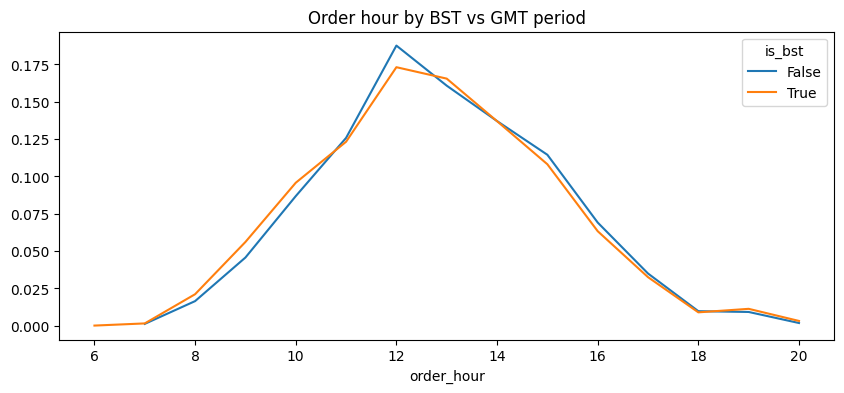

In [8]:
df['month']      = df['InvoiceDateMin'].dt.month
df['is_bst']     = df['month'].between(4, 10)   # rough BST window (Apr-Oct)

# Compare hour distributions for BST vs GMT periods
hour_dist = (df.groupby(['is_bst','order_hour']).size()
               .unstack(level=0)
               .div(df.groupby('is_bst').size()))    # normalise to proportion within each period
hour_dist.plot(kind='line', figsize=(10,4), title='Order hour by BST vs GMT period')

---
We update most common customer country as country_mode

In [9]:
# Most common country per customer (handles ties by taking the first alphabetically)
country_mode = (df.groupby('CustomerHashID')['Country']
                  .agg(lambda x: x.mode().iloc[0])
                  .rename('country_mode'))

customer = customer.drop(columns=['country_mode'], errors='ignore')
customer = customer.merge(country_mode, on='CustomerHashID', how='left')

we check how many customers order from multiple countries. 12

In [10]:
# How many customers ordered from more than one country?
multi_country = df.groupby('CustomerHashID')['Country'].nunique()
print('Customers with >1 country:', (multi_country > 1).sum())
print('Distribution:')
print(multi_country.value_counts().sort_index())

Customers with >1 country: 12
Distribution:
Country
1    5837
2      12
Name: count, dtype: int64


We look at monthly_revenue_trajectory — slope of monthly spend over their activity span (for lifecycle "growing/declining")

In [11]:
import numpy as np
from scipy.stats import linregress

def monthly_slope(group):
    monthly = group.set_index('InvoiceDateMin')['TotalPrice'].resample('ME').sum()
    if len(monthly) < 3:
        return np.nan
    return linregress(range(len(monthly)), monthly.values).slope

slopes = (df.groupby('CustomerHashID').apply(monthly_slope, include_groups=False)
            .rename('rev_slope'))

customer = customer.drop(columns=['rev_slope','rev_slope_pct'], errors='ignore')
customer = customer.merge(slopes, on='CustomerHashID', how='left')

# Normalised version — slope as % of avg monthly revenue, comparable across customer sizes
avg_monthly_rev = customer['total_revenue'] / (customer['active_span_days'] / 30.44)
customer['rev_slope_pct'] = customer['rev_slope'] / avg_monthly_rev

I am not sure about simple linear regtression for monthly trend as a feature. Let's look at an account:  

<Axes: title={'center': 'Monthly revenue: customer 72ed2bc3'}, xlabel='InvoiceDateMin'>

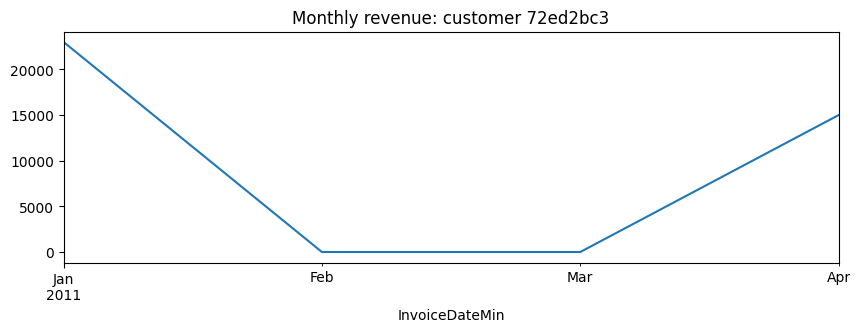

In [12]:
cust_chk = customer.loc[customer['rev_slope'].idxmin(), 'CustomerHashID'] 
inspect = (df[df['CustomerHashID'] == cust_chk]
           .set_index('InvoiceDateMin')['TotalPrice']
           .resample('ME').sum())
inspect.plot(title=f'Monthly revenue: customer {cust_chk[:8]}', figsize=(10,3))

the above graph shows that the liner trajectory is a bit blunt for this customer since this looks more like they stocked up in Jan 2011 and then only needed a restock in Apr so we need to take different types of activity like they order monthly etc.

---
We add active_months to assist with diagnosing this type of thing later
- I will look at it when I need it

In [13]:
# Number of active months — useful for filtering slopes downstream
n_active_months = (df.assign(month=df['InvoiceDateMin'].dt.to_period('M'))
                     .groupby('CustomerHashID')['month']
                     .nunique()
                     .rename('n_active_months'))

customer = customer.drop(columns=['n_active_months'], errors='ignore')
customer = customer.merge(n_active_months, on='CustomerHashID', how='left')

I just check the distribution

In [14]:
customer['n_active_months'].describe()

count    5849.000000
mean        4.352881
std         4.487245
min         1.000000
25%         1.000000
50%         3.000000
75%         6.000000
max        25.000000
Name: n_active_months, dtype: float64

---
---
# We Look at Firmographic

In [15]:
# Check the country list and count
uniq_country = customer.groupby('country_mode')['country_mode'].value_counts().sort_index()
print(uniq_country)

country_mode
AUSTRALIA                 14
AUSTRIA                   11
BAHRAIN                    2
BELGIUM                   28
BRAZIL                     2
CANADA                     5
CHANNEL ISLANDS           13
CYPRUS                    10
CZECH REPUBLIC             1
DENMARK                    9
EUROPEAN COMMUNITY         1
FINLAND                   13
FRANCE                    93
GERMANY                  106
GREECE                     5
ICELAND                    1
IRELAND                    3
ISRAEL                     4
ITALY                     17
JAPAN                     10
KOREA                      2
LEBANON                    1
LITHUANIA                  1
MALTA                      2
NETHERLANDS               22
NIGERIA                    1
NORWAY                    12
POLAND                     6
PORTUGAL                  22
SAUDI ARABIA               1
SINGAPORE                  1
SOUTH AFRICA               2
SPAIN                     35
SWEDEN                    19
S

---
## We apply the following groupings:
| **country_mode**     | **region**      | **sub_region**            | **count** |
| :------------------- | :-------------- | :------------------------ | :-------- |
| AUSTRALIA            | APAC            | OCEANIA                   | 14        |
| AUSTRIA              | EMEA            | EUROPE / DACH             | 11        |
| BAHRAIN              | EMEA            | MIDDLE EAST               | 2         |
| BELGIUM              | EMEA            | EUROPE / BENELUX          | 28        |
| BRAZIL               | AMER            | AMER / LATAM              | 2         |
| CANADA               | AMER            | AMER / NORAM              | 5         |
| CHANNEL ISLANDS      | CHANNEL ISLANDS | CHANNEL ISLANDS           | 13        |
| CYPRUS               | EMEA            | EUROPE / MEDITERRANEAN    | 10        |
| CZECH REPUBLIC       | EMEA            | EUROPE / CEE              | 1         |
| DENMARK              | EMEA            | EUROPE / NORDICS          | 9         |
| EUROPEAN COMMUNITY   | EMEA            | POLITICAL/REGIONAL ENTITY | 1         |
| FINLAND              | EMEA            | EUROPE / NORDICS          | 13        |
| FRANCE               | EMEA            | EUROPE / CENTRAL          | 93        |
| GERMANY              | EMEA            | EUROPE / DACH             | 106       |
| GREECE               | EMEA            | EUROPE / MEDITERRANEAN    | 5         |
| ICELAND              | EMEA            | EUROPE / NORDICS          | 1         |
| IRELAND              | EMEA            | EUROPE / NORTHERN         | 3         |
| ISRAEL               | EMEA            | MIDDLE EAST               | 4         |
| ITALY                | EMEA            | EUROPE / MEDITERRANEAN    | 17        |
| JAPAN                | APAC            | EAST ASIA                 | 10        |
| KOREA                | APAC            | EAST ASIA                 | 2         |
| LEBANON              | EMEA            | MIDDLE EAST               | 1         |
| LITHUANIA            | EMEA            | EUROPE / BALTICS          | 1         |
| MALTA                | EMEA            | EUROPE / MEDITERRANEAN    | 2         |
| NETHERLANDS          | EMEA            | EUROPE / BENELUX          | 22        |
| NIGERIA              | EMEA            | AFRICA                    | 1         |
| NORWAY               | EMEA            | EUROPE / NORDICS          | 12        |
| POLAND               | EMEA            | EUROPE / CEE              | 6         |
| PORTUGAL             | EMEA            | EUROPE / IBERIA           | 22        |
| SAUDI ARABIA         | EMEA            | MIDDLE EAST               | 1         |
| SINGAPORE            | APAC            | SOUTHEAST ASIA            | 1         |
| SOUTH AFRICA         | EMEA            | AFRICA                    | 2         |
| SPAIN                | EMEA            | EUROPE / IBERIA           | 35        |
| SWEDEN               | EMEA            | EUROPE / NORDICS          | 19        |
| SWITZERLAND          | EMEA            | EUROPE / DACH             | 22        |
| THAILAND             | APAC            | SOUTHEAST ASIA            | 1         |
| UNITED ARAB EMIRATES | EMEA            | MIDDLE EAST               | 4         |
| UNITED KINGDOM       | UK DOMESTIC     | UK DOMESTIC               | 5332      |
| UNITED STATES        | AMER            | AMER / NORAM              | 8         |
| UNSPECIFIED          | UNSPECIFIED     | UNSPECIFIED               | 6         |
| WEST INDIES          | AMER            | AMER / LATAM              | 1         |
| **TOTAL**            | **TOTAL**       | **TOTAL**                 | **5,849** |

In [16]:
# Country — actually present
customer['country_mode']

# Region — derived from country
def country_to_region(c):
    if c == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif c == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif c == 'UNSPECIFIED':
        return 'UNSPECIFIED'
    elif c in ['BRAZIL', 'CANADA', 'UNITED STATES', 'WEST INDIES']:
        return 'AMER'
    elif c in ['AUSTRALIA', 'JAPAN', 'KOREA' ,'SINGAPORE' ,'THAILAND']:
        return 'APAC'
    else:
        return 'EMEA'
    
# Sub-Region — derived from country
def country_to_subregion(cs):
    if cs == 'UNITED KINGDOM':
        return 'UK DOMESTIC'
    elif cs == 'CHANNEL ISLANDS':
        return 'CHANNEL ISLANDS'
    elif cs == 'IRELAND':
        return 'EUROPE / NORTHERN'
    elif cs in ['BRAZIL', 'WEST INDIES']:
        return 'AMER / LATAM'
    elif cs in ['CANADA', 'UNITED STATES']:
        return 'AMER / NORAM'
    elif cs in ['AUSTRALIA']:
        return 'OCEANIA'
    elif cs == 'EUROPEAN COMMUNITY':
        return 'POLITICAL / REGIONAL ENTITY'
    elif cs in ['AUSTRIA', 'GERMANY', 'SWITZERLAND']:
        return 'EUROPE / DACH'
    elif cs in ['BELGIUM', 'NETHERLANDS']:
        return 'EUROPE / BENELUX'
    elif cs in ['CYPRUS', 'GREECE', 'ITALY', 'MALTA']:
        return 'EUROPE / MEDITERRANEAN'
    elif cs in ['CZECH REPUBLIC', 'POLAND']:
        return 'EUROPE / CEE'
    elif cs in ['DENMARK', 'FINLAND', 'ICELAND', 'NORWAY', 'SWEDEN']:
        return 'EUROPE / NORDICS'
    elif cs in ['FRANCE']:
        return 'EUROPE / CENTRAL'
    elif cs in ['LITHUANIA']:
        return 'EUROPE / BALTICS'
    elif cs in ['PORTUGAL', 'SPAIN']:
        return 'EUROPE / IBERIA'
    elif cs in ['BAHRAIN', 'ISRAEL', 'LEBANON', 'SAUDI ARABIA', 'UNITED ARAB EMIRATES']:
        return 'MIDDLE EAST'
    elif cs in ['JAPAN', 'KOREA']:
        return 'EAST ASIA'
    elif cs in ['SINGAPORE' ,'THAILAND']:
        return 'SOUTHEAST ASIA'
    elif cs in ['NIGERIA', 'SOUTH AFRICA']:
        return 'AFRICA'
    else:
        return 'UNSPECIFIED'

customer['region'] = customer['country_mode'].apply(country_to_region)
customer['sub_region'] = customer['country_mode'].apply(country_to_subregion)

# naming convention change KOREA to SOUTH KOREA
customer['country_mode'] = customer['country_mode'].replace('KOREA', 'SOUTH KOREA')

In [17]:
# Check the region list and count
# Option 3 — as a tidy DataFrame with a named count column (nicest for further use)
uniq_region = (customer.groupby(['region','sub_region'])
                       .size()
                       .reset_index(name='n_customers')
                       .sort_values(['region','sub_region']))
print(uniq_region)

             region                   sub_region  n_customers
0              AMER                 AMER / LATAM            3
1              AMER                 AMER / NORAM           13
2              APAC                    EAST ASIA           12
3              APAC                      OCEANIA           14
4              APAC               SOUTHEAST ASIA            2
5   CHANNEL ISLANDS              CHANNEL ISLANDS           13
6              EMEA                       AFRICA            3
7              EMEA             EUROPE / BALTICS            1
8              EMEA             EUROPE / BENELUX           50
9              EMEA                 EUROPE / CEE            7
10             EMEA             EUROPE / CENTRAL           93
11             EMEA                EUROPE / DACH          139
12             EMEA              EUROPE / IBERIA           57
13             EMEA       EUROPE / MEDITERRANEAN           34
14             EMEA             EUROPE / NORDICS           54
15      

---
---
# RFM and Seasonality

In [18]:
import pandas as pd
import numpy as np

# RECENCY — lower days = better, so labels run 5→1 (most recent gets 5)
customer['R'] = pd.qcut(customer['recency_days'],
                        q=5,
                        labels=[5, 4, 3, 2, 1],
                        duplicates='drop').astype(int)

# FREQUENCY — many customers have n_invoices = 1, 2, 3, which causes qcut
# to fail on duplicate quantile edges. Rank-then-qcut breaks ties cleanly.
customer['F'] = pd.qcut(customer['n_invoices'].rank(method='first'),
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# MONETARY — higher revenue = better
customer['M'] = pd.qcut(customer['total_revenue'],
                        q=5,
                        labels=[1, 2, 3, 4, 5]).astype(int)

# Combined score for sorting/sanity-checking
customer['RFM_score'] = customer[['R','F','M']].sum(axis=1)
customer['RFM_cell'] = (customer['R'].astype(str) +
                        customer['F'].astype(str) +
                        customer['M'].astype(str))

In [19]:
# Each bucket should contain ~20% of customers
customer[['R','F','M']].apply(lambda c: c.value_counts(normalize=True).sort_index())

,R,F,M
1,0.198837,0.200034,0.200205
2,0.200376,0.200034,0.199863
3,0.197470,0.199863,0.199863
4,0.200889,0.200034,0.200034
5,0.202428,0.200034,0.200034


count    5849.000000
mean        9.007523
std         3.643756
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_score, dtype: float64


<Axes: >

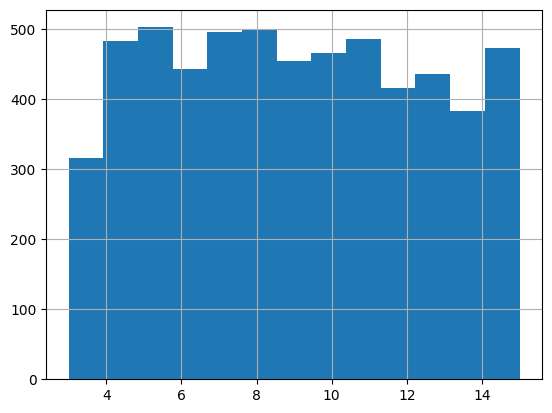

In [20]:
# Top 10 most populated RFM cells — shows where your customer base concentrates
# print(customer['RFM_cell'].value_counts().head(10))

# RFM_score distribution — should look roughly normal-ish, peaked around 9
print(customer['RFM_score'].describe())
customer['RFM_score'].hist(bins=13)

In [21]:
# Quick check to confirm the corners are dense
print(customer['RFM_cell'].value_counts().head(5))
# (1,1,1) and (5,5,5) should both feature prominently

RFM_cell
555    473
111    316
455    253
121    170
211    169
Name: count, dtype: int64


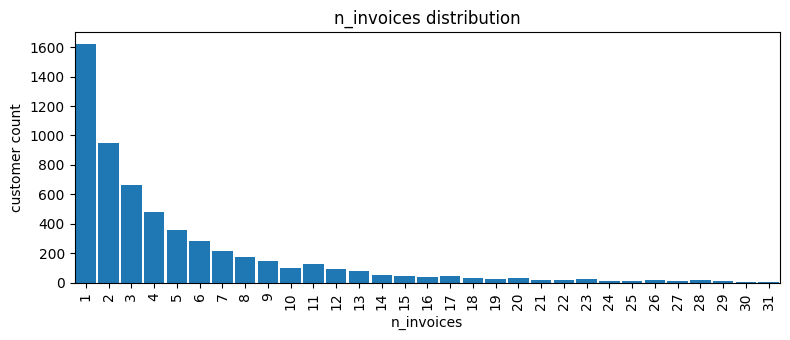

In [22]:
import matplotlib.pyplot as plt

# Two views — linear and log-y, so you can see both the peak and the tail
plt.figure(figsize=(8, 3.5))

customer['n_invoices'].value_counts().sort_index().plot.bar(width=0.9)
plt.title('n_invoices distribution')
plt.xlabel('n_invoices')
plt.ylabel('customer count')
plt.xlim(-0.5, 30.5)   # zoom to the dense part

plt.tight_layout(); plt.show()

In [23]:
for col in ['R','F','M']:
    print(f'{col} bucket sizes:')
    print(customer[col].value_counts().sort_index())
    print()

R bucket sizes:
R
1    1163
2    1172
3    1155
4    1175
5    1184
Name: count, dtype: int64

F bucket sizes:
F
1    1170
2    1170
3    1169
4    1170
5    1170
Name: count, dtype: int64

M bucket sizes:
M
1    1171
2    1169
3    1169
4    1170
5    1170
Name: count, dtype: int64



In [24]:
print('Recency (days since last purchase) by R bucket:')
print(customer.groupby('R')['recency_days'].agg(['min','max','count']))

print('\nFrequency (n_invoices) by F bucket:')
print(customer.groupby('F')['n_invoices'].agg(['min','max','count']))

print('\nMonetary (total_revenue) by M bucket:')
print(customer.groupby('M')['total_revenue'].agg(['min','max','count']))

Recency (days since last purchase) by R bucket:
   min  max  count
R                 
1  409  737   1163
2  187  408   1172
3   59  186   1155
4   19   58   1175
5    0   18   1184

Frequency (n_invoices) by F bucket:
   min  max  count
F                 
1    1    1   1170
2    1    2   1170
3    2    4   1169
4    4    8   1170
5    8  370   1170

Monetary (total_revenue) by M bucket:
       min        max  count
M                           
1     2.90     288.10   1171
2   288.42     612.78   1169
3   612.94    1227.54   1169
4  1229.95    2940.36   1170
5  2942.31  607539.25   1170


In [25]:
customer.loc[customer['F']==5, 'n_invoices'].describe()
customer.loc[customer['F']==5, 'n_invoices'].quantile([0.5, 0.75, 0.9, 0.95, 0.99])

0.50     13.00
0.75     20.00
0.90     33.00
0.95     45.00
0.99    122.55
Name: n_invoices, dtype: float64

---
### Now we apply lifecycle labels

In [26]:
def lifecycle_label(row):
    r, f, m = row['R'], row['F'], row['M']

    # Top-tier High-Value engaged
    if r >= 4 and f >= 4 and m >= 4:        return 'Champions'
    if r == 3 and f >= 4 and m >= 4:        return 'Loyal'
    if r <= 2 and f >= 4 and m >= 4:        return 'Cannot Lose Them'

    # Top-tier engaged
    if r >= 4 and f >= 4 and m == 3:        return 'Champions Lower-Value'
    if r == 3 and f >= 4 and m == 3:        return 'Loyal Lower-Value'
    if r <= 2 and f >= 4 and m <= 3:        return 'Cannot Lose Lower-Value'

    # New / acquisition phase
    if r >= 4 and f <= 2:                   return 'New / Promising'

    # Mid-tier engaged
    if r >= 3 and f >= 3 and m <= 2:        return 'Frequent Low-Spend'
    if r >= 3 and f == 3 and m >= 3:        return 'About to Sleep'

    # Mid-recency drift
    if r == 3 and f <= 2:                   return 'Needs Attention'

    # Lapsing / lapsed
    if r <= 2 and f == 3:                   return 'At Risk'
    if r <= 2 and f <= 2 and m >= 4:        return 'Lost High-Value'
    if r <= 2 and f <= 2 and m <= 3:        return 'Hibernating / Lost'
    
    # Catch-all: should be empty.
    return 'UNCLASSIFIED'

customer['lifecycle_segment'] = customer.apply(lifecycle_label, axis=1)

# Sanity check the distribution
print(customer['lifecycle_segment'].value_counts())

lifecycle_segment
Hibernating / Lost         1451
Champions                  1301
About to Sleep              486
At Risk                     466
New / Promising             451
Loyal                       398
Needs Attention             373
Frequent Low-Spend          265
Cannot Lose Them            237
Champions Lower-Value       160
Cannot Lose Lower-Value     116
Loyal Lower-Value            80
Lost High-Value              65
Name: count, dtype: int64


In [27]:
# 1. Filter the dataframe to ONLY the unclassified customers
unclassified = customer[customer['lifecycle_segment'] == 'UNCLASSIFIED'].copy()

# 2. Combine the R, F, and M columns into a single string (e.g., R=2, F=2, M=3 becomes '223')
unclassified['RFM_pattern'] = (
    unclassified['R'].astype(str) + 
    unclassified['F'].astype(str) + 
    unclassified['M'].astype(str)
)

# 3. Print the counts of these missing patterns
print("Missing RFM Combinations (R-F-M):")
print(unclassified['RFM_pattern'].value_counts())

Missing RFM Combinations (R-F-M):
Series([], Name: count, dtype: int64)


Champions and Hibernating are about 22% each. We can check hibernating versus seaonaility later, lets look at grapphs

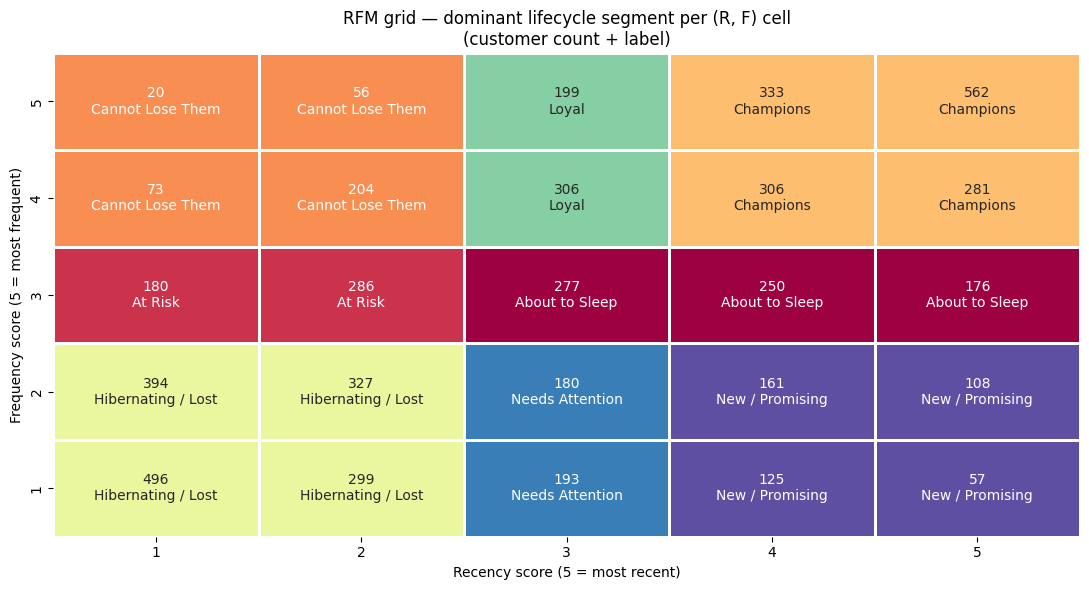

In [28]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

# Build the label→int map
labels_unique = sorted(customer['lifecycle_segment'].dropna().unique())
label_to_int  = {lbl: i for i, lbl in enumerate(labels_unique)}
int_to_label  = {i: lbl for lbl, i in label_to_int.items()}

# Add an integer code column on customer, then groupby it directly — avoids dtype issues
customer['_lifecycle_code'] = customer['lifecycle_segment'].map(label_to_int)

# For each (R, F) cell, take the modal code
grid_numeric = (customer.groupby(['F','R'])['_lifecycle_code']
                        .agg(lambda x: x.mode().iloc[0])
                        .unstack('R')
                        .astype(float))

# Customer counts per cell
counts = (customer.groupby(['F','R']).size()
                  .unstack('R').fillna(0).astype(int))

# Build annotation: "count\nlabel" for populated cells, '' for empty
annot = pd.DataFrame('', index=grid_numeric.index, columns=grid_numeric.columns)
for r in grid_numeric.index:
    for c in grid_numeric.columns:
        v = grid_numeric.loc[r, c]
        if pd.notna(v):
            annot.loc[r, c] = f"{counts.loc[r, c]:,}\n{int_to_label[int(v)]}"

# Plot
fig, ax = plt.subplots(figsize=(11, 6))
sns.heatmap(grid_numeric.iloc[::-1],         # flip so F=5 sits at the top
            annot=annot.iloc[::-1],
            fmt='',
            cmap='Spectral',
            cbar=False,
            linewidths=1,
            linecolor='white',
            ax=ax)
ax.set_title('RFM grid — dominant lifecycle segment per (R, F) cell\n(customer count + label)')
ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
plt.tight_layout()
plt.show()

# Tidy up
customer = customer.drop(columns='_lifecycle_code')

In [29]:
print(grid_numeric.dtypes)
print(grid_numeric)

R
1    float64
2    float64
3    float64
4    float64
5    float64
dtype: object
R    1    2     3     4     5
F                            
1  7.0  7.0  11.0  12.0  12.0
2  7.0  7.0  11.0  12.0  12.0
3  1.0  1.0   0.0   0.0   0.0
4  3.0  3.0   9.0   4.0   4.0
5  3.0  3.0   9.0   4.0   4.0


In [ ]:
# !pip install squarify

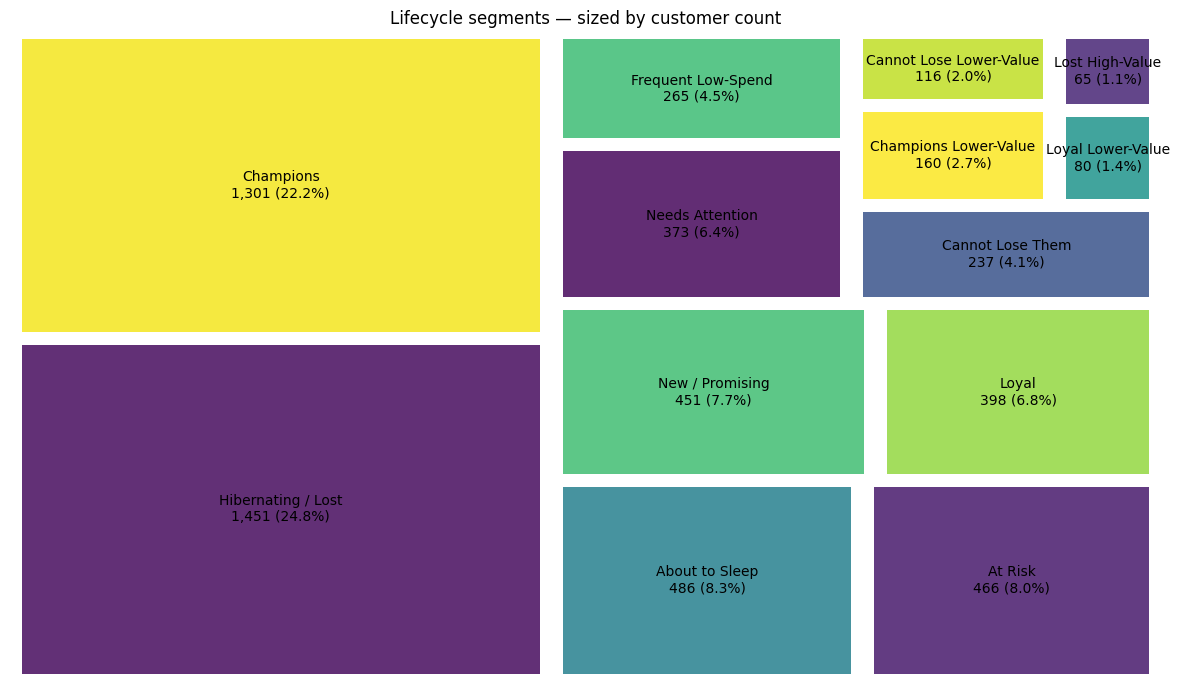

In [30]:
import squarify
import matplotlib.pyplot as plt

seg_counts = customer['lifecycle_segment'].value_counts()
labels = [f'{name}\n{count:,} ({count/len(customer)*100:.1f}%)'
          for name, count in seg_counts.items()]

plt.figure(figsize=(12, 7))
squarify.plot(sizes=seg_counts.values,
              label=labels,
              alpha=0.85,
              pad=True,
              text_kwargs={'fontsize': 10, 'wrap': True})
plt.title('Lifecycle segments — sized by customer count')
plt.axis('off')
plt.tight_layout()
plt.show()

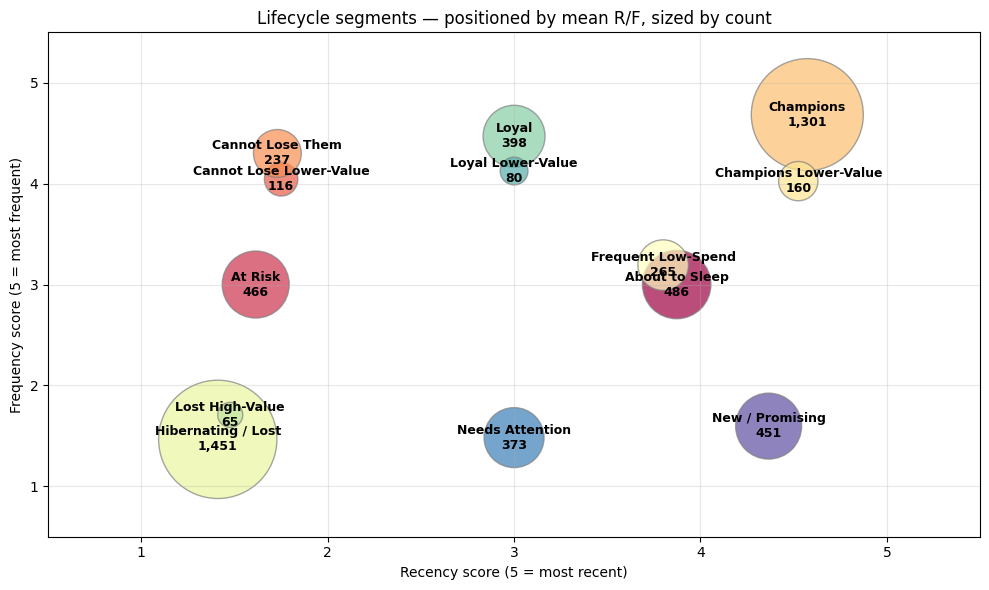

In [31]:
import matplotlib.pyplot as plt
import numpy as np

# Compute centroid (R,F) for each segment, weighted by count, plus segment size
seg_summary = (customer.groupby('lifecycle_segment')
                       .agg(R_mean=('R','mean'),
                            F_mean=('F','mean'),
                            count=('CustomerHashID','count'))
                       .reset_index())

fig, ax = plt.subplots(figsize=(10, 6))
scatter = ax.scatter(seg_summary['R_mean'],
                     seg_summary['F_mean'],
                     s=seg_summary['count'] * 5,    # bubble size
                     c=range(len(seg_summary)),
                     cmap='Spectral',
                     alpha=0.7,
                     edgecolors='grey',
                     linewidth=1)

# Label each bubble with segment name and count
for _, row in seg_summary.iterrows():
    ax.annotate(f"{row['lifecycle_segment']}\n{row['count']:,}",
                (row['R_mean'], row['F_mean']),
                ha='center', va='center', fontsize=9, fontweight='bold')

ax.set_xlabel('Recency score (5 = most recent)')
ax.set_ylabel('Frequency score (5 = most frequent)')
ax.set_title('Lifecycle segments — positioned by mean R/F, sized by count')
ax.set_xlim(0.5, 5.5); ax.set_ylim(0.5, 5.5)
ax.set_xticks(range(1, 6)); ax.set_yticks(range(1, 6))
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

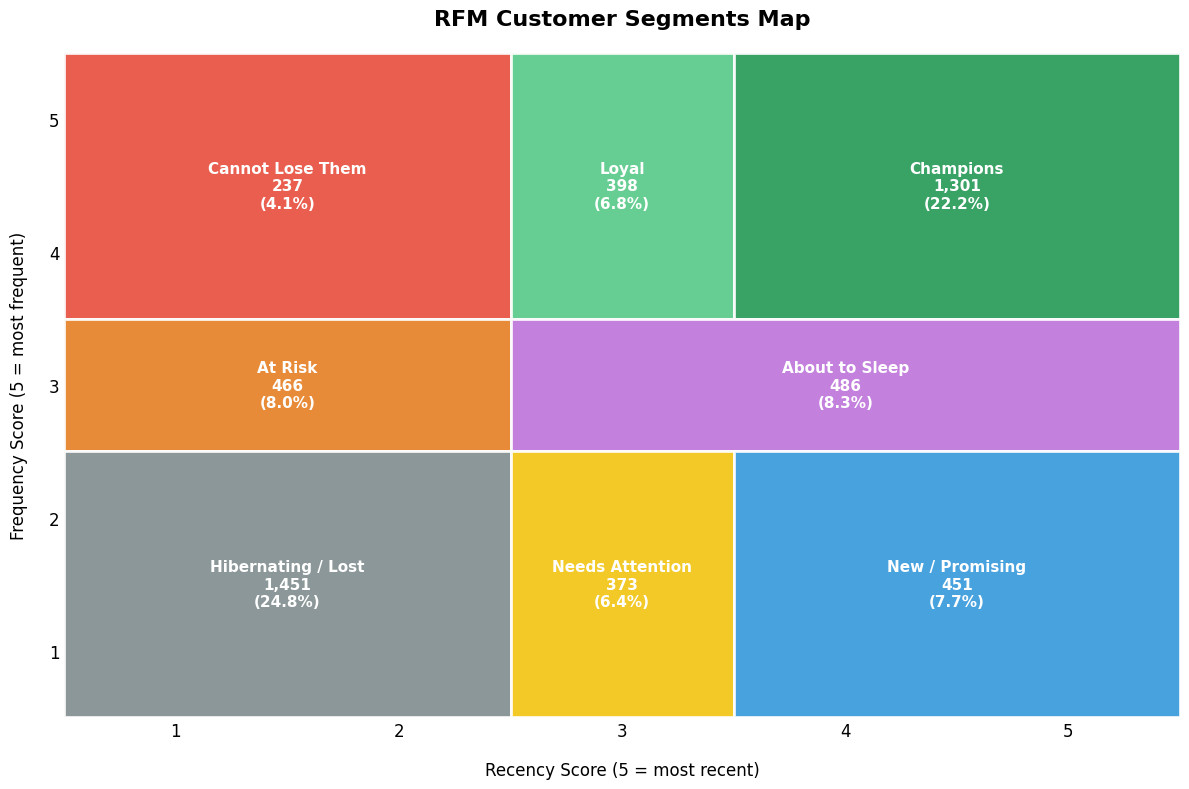

In [32]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches

# 1. Get customer counts and percentages (same as your previous code)
seg_counts = customer['lifecycle_segment'].value_counts()
total_customers = len(customer)

# 2. Use your exact custom color map
colour_map = {
    'Champions':           "#239854",
    'Loyal':               "#55c986",
    'Cannot Lose Them':         '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 '#bd72da',
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. Define the fixed coordinates for each segment on a 5x5 grid.
# Format: 'Segment Name': (x_start, y_start, width, height)
# x = Recency (0 to 5), y = Frequency (0 to 5)
segment_boxes = {
    'Cannot Lose Them':   (0, 3, 2, 2),  # R:1-2, F:4-5
    'Loyal':         (2, 3, 1, 2),  # R:3,   F:4-5
    'Champions':     (3, 3, 2, 2),  # R:4-5, F:4-5
    
    'At Risk':                  (0, 2, 2, 1),  # R:1-2, F:3
    'About to Sleep':           (2, 2, 3, 1),  # R:3-5, F:3
    
    'Hibernating / Lost':       (0, 0, 2, 2),  # R:1-2, F:1-2
    'Needs Attention':          (2, 0, 1, 2),  # R:3,   F:1-2
    'New / Promising':          (3, 0, 2, 2),  # R:4-5, F:1-2
}

# Create the figure
fig, ax = plt.subplots(figsize=(12, 8))

# 4. Loop through the boxes, draw them, and add the text
for seg, (x, y, w, h) in segment_boxes.items():
    
    # Get the count and calc percentage (handle missing segments gracefully)
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    label_text = f"{seg}\n{count:,}\n({pct:.1f}%)"
    
    # Draw the rectangle
    rect = patches.Rectangle(
        (x, y), w, h, 
        linewidth=2, 
        edgecolor='white', # Creates the gap/border between boxes
        facecolor=colour_map.get(seg, '#333333'), 
        alpha=0.9
    )
    ax.add_patch(rect)
    
    # Add the text in the center of the rectangle
    ax.text(
        x + w/2, y + h/2, 
        label_text, 
        ha='center', va='center', 
        color='white', fontsize=11, fontweight='bold',
        wrap=True
    )

# 5. Format the axes to look like an RFM grid
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)

# Set ticks to be in the middle of the blocks (0.5, 1.5, 2.5, etc.)
ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])

# Label the ticks 1 to 5
ax.set_xticklabels(['1', '2', '3', '4', '5'], fontsize=12)
ax.set_yticklabels(['1', '2', '3', '4', '5'], fontsize=12)

ax.set_xlabel('Recency Score (5 = most recent)', fontsize=12, labelpad=15)
ax.set_ylabel('Frequency Score (5 = most frequent)', fontsize=12, labelpad=15)
ax.set_title('RFM Customer Segments Map', fontsize=16, fontweight='bold', pad=20)

# Remove the outer spines for a cleaner look
for spine in ax.spines.values():
    spine.set_visible(False)

# Remove tick marks (keep the labels)
ax.tick_params(axis='both', which='both', length=0)

plt.tight_layout()
plt.show()

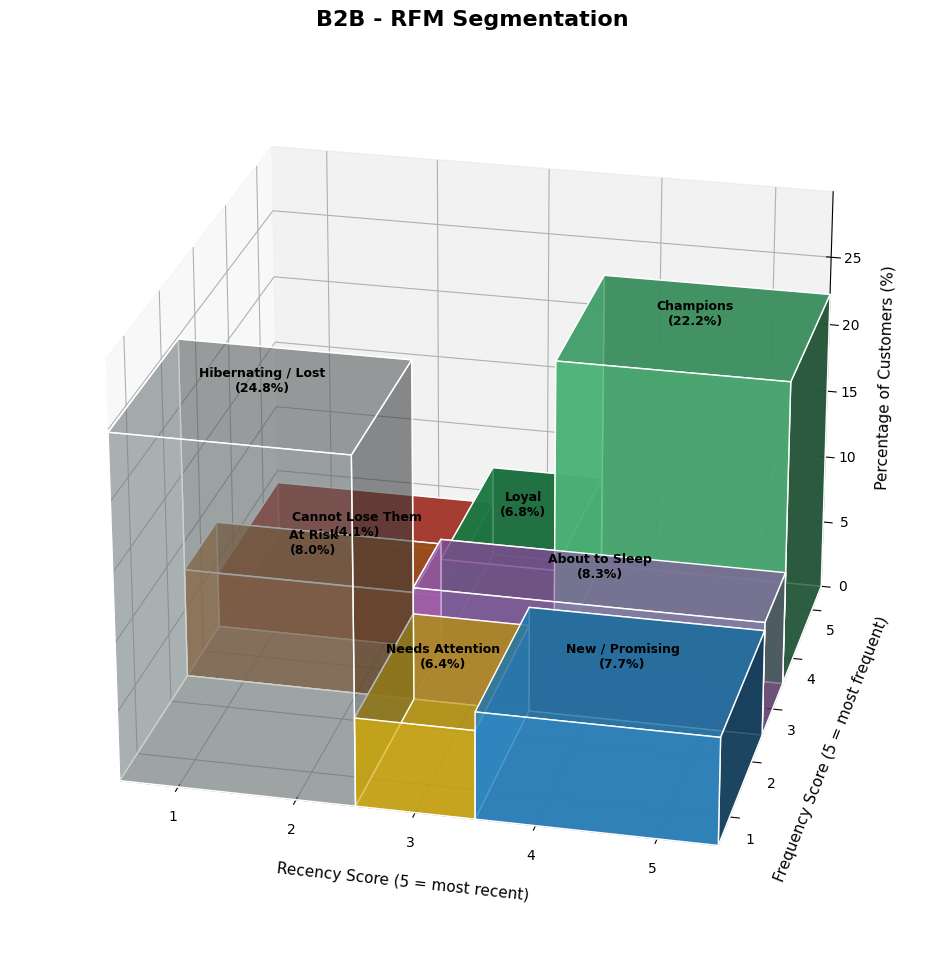

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors  # <-- NEW: Required for RGBA color conversion
from mpl_toolkits.mplot3d import Axes3D

# 1. Setup counts and total
seg_counts = customer['lifecycle_segment'].value_counts()
total_customers = len(customer)

# 2. Colour Map (Base Colors)
colour_map = {
    'Champions':           '#55c986',
    'Loyal':               '#239854',
    'Cannot Lose Them':         '#e74c3c',
    'At Risk':                        '#e67e22',
    'Needs Attention':                '#f1c40f',
    'About to Sleep':                 "#bd72da",
    'Hibernating / Lost':             '#7f8c8d',
    'New / Promising':                '#3498db',
    'Frequent Low-Spend':             "#9b59b6", 
}

# 3. NEW: Alpha (Transparency) Map
# 1.0 is completely solid, 0.0 is invisible.
# We make the tall blocks in the front transparent, and the short blocks in the back solid.
alpha_map = {
    'Hibernating / Lost':        0.35, # Very transparent
    'At Risk':                   0.50, # Semi-transparent
    'About to Sleep':            0.60, 
    'Needs Attention':           0.70, 
    'New / Promising':           0.85, # Mostly solid 
    'Loyal High-Value':          0.85, 
    'Champions High-Value':      0.95, 
    'Cannot Lose High-Value':    1.0,  # Opaque to see it
}

# Fixed Grid Coordinates: 'Segment': (x_start, y_start, width, depth)
segment_boxes = {
    'Cannot Lose Them':    (0, 3, 2, 2),  
    'Loyal':          (2, 3, 1, 2),  
    'Champions':      (3, 3, 2, 2),  
    'At Risk':                   (0, 2, 2, 1),  
    'About to Sleep':            (2, 2, 3, 1),  
    'Hibernating / Lost':        (0, 0, 2, 2),  
    'Needs Attention':           (2, 0, 1, 2),  
    'New / Promising':           (3, 0, 2, 2),  
}

fig = plt.figure(figsize=(12,12))
ax = fig.add_subplot(111, projection='3d')

x_pos, y_pos, z_pos = [], [], []
dx, dy, dz = [], [], []
colors = []
max_pct = 0

# 4. Build the 3D data arrays
for seg, (x, y, w, h) in segment_boxes.items():
    count = seg_counts.get(seg, 0)
    pct = (count / total_customers) * 100
    if pct > max_pct: max_pct = pct

    x_pos.append(x)
    y_pos.append(y)
    z_pos.append(0) 
    
    dx.append(w)
    dy.append(h)
    dz.append(pct)
    
    # --- NEW COLOR LOGIC ---
    base_color = colour_map.get(seg, '#333333')
    alpha_val = alpha_map.get(seg, 0.8) # Default to 0.8 if not in the alpha map
    
    # Convert hex to RGBA using Matplotlib's to_rgba
    rgba_color = mcolors.to_rgba(base_color, alpha_val)
    colors.append(rgba_color)
    # -----------------------

    # Add text floating slightly above the block
    label_text = f"{seg}\n({pct:.1f}%)"
    
    # Optional tweak: If you still can't read the text for the hidden blocks, 
    # you can artificially raise the text height so it floats above the grey blocks.
    # text_z = max(pct + 1.0, 15.0) if seg == 'Cannot Lose Them' else pct + 1.0
    text_z = pct + 1.0 
    
    ax.text(
        x + (w / 2), y + (h / 2), text_z, 
        label_text, 
        ha='center', va='center', 
        fontsize=9, fontweight='bold', color='black'
    )

# 5. Draw the 3D blocks
ax.bar3d(
    x_pos, y_pos, z_pos, 
    dx, dy, dz, 
    color=colors,         # Now using our custom RGBA list
    edgecolor='white',  
    shade=True            
    # REMOVED alpha=0.9 from here!
)

# Formatting the Axes
ax.set_xlim(0, 5)
ax.set_ylim(0, 5)
z_limit = max(25, max_pct + 5) 
ax.set_zlim(0, z_limit)

ax.set_xticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_yticks([0.5, 1.5, 2.5, 3.5, 4.5])
ax.set_xticklabels(['1', '2', '3', '4', '5'])
ax.set_yticklabels(['1', '2', '3', '4', '5'])

ax.set_xlabel('\nRecency Score (5 = most recent)', fontsize=11, linespacing=3)
ax.set_ylabel('\nFrequency Score (5 = most frequent)', fontsize=11, linespacing=3)
ax.set_zlabel('Percentage of Customers (%)', fontsize=11, labelpad=10)

plt.title('B2B - RFM Segmentation', fontsize=16, fontweight='bold', pad=0)

ax.view_init(elev=24, azim=-77) 
plt.show()

##### Now the above is starting to look like what I want. I need to format it better (like the text) but it becomes obvious to see the groups and their size.
I need to change the colours

Okay I still need to do seasonality and the slice and dice to understand Champion persona since 22% Champion and 22% Hibernting / Lost is a different lense depending on persona.

---
### We look at the share of revenue defined as tier_value
Key accounts (expected 20% or so of accounts for 80% or so of revenue), Mid and long tail

In [34]:
# Sort by revenue, compute cumulative share
customer = customer.sort_values('total_revenue', ascending=False).reset_index(drop=True)
customer['cum_rev_pct'] = customer['total_revenue'].cumsum() / customer['total_revenue'].sum()

def value_tier(pct):
    if pct <= 0.80:  return 'Key Account'    # top customers driving 80% of revenue
    if pct <= 0.95:  return 'Mid'            # next chunk driving 15%
    return 'Long Tail'                       # everyone else

customer['value_tier'] = customer['cum_rev_pct'].apply(value_tier)

print(customer['value_tier'].value_counts())
print(customer.groupby('value_tier')['total_revenue'].agg(['count','sum','median']))

value_tier
Long Tail      2586
Mid            1888
Key Account    1375
Name: count, dtype: int64
             count          sum    median
value_tier                               
Key Account   1375  13654875.30  4667.570
Long Tail     2586    853540.76   310.775
Mid           1888   2561106.42  1246.615


---
### Look at Trajectory using rev_slope_pct + n_active_months

In [35]:
# Define "trustworthy" slope: at least 3 active months
trustworthy = customer['n_active_months'] >= 3

# Tercile the trustworthy slopes — top 1/3 = Growing, bottom 1/3 = Declining
upper_cut = customer.loc[trustworthy, 'rev_slope_pct'].quantile(0.66)
lower_cut = customer.loc[trustworthy, 'rev_slope_pct'].quantile(0.33)

def trajectory_label(row):
    if row['n_active_months'] < 3 or pd.isna(row['rev_slope_pct']):
        return 'Insufficient data'
    if row['rev_slope_pct'] >= upper_cut: return 'Growing'
    if row['rev_slope_pct'] <= lower_cut: return 'Declining'
    return 'Stable'

customer['trajectory'] = customer.apply(trajectory_label, axis=1)

print(customer['trajectory'].value_counts())
print(f"Growing threshold: {upper_cut:.3f} ({upper_cut*100:.1f}% per month)")
print(f"Declining threshold: {lower_cut:.3f} ({lower_cut*100:.1f}% per month)")

trajectory
Insufficient data    2832
Growing              1026
Declining             996
Stable                995
Name: count, dtype: int64
Growing threshold: 0.013 (1.3% per month)
Declining threshold: -0.046 (-4.6% per month)


---
### Let's check lifecycle_segment, value_tier and trajectory

In [45]:
# 1 Are Cannot Lose Them customers actually high-value? They should be.
# pd.crosstab(customer['lifecycle_segment'], customer['value_tier'])

# 2 Are Champions usually Growing or Stable? Mostly yes? — declining champions are rare.
pd.crosstab(customer['lifecycle_segment'], customer['trajectory'])

# 3 The three-way matrix of populated personas. Note this is the first draft
# I still need seasonality, k-means on behviour, product affinity but this is a starting point for refining
# pd.crosstab([customer['lifecycle_segment'], customer['value_tier']], customer['trajectory'])

trajectory,Declining,Growing,Insufficient data,Stable
lifecycle_segment,,,,
About to Sleep,146,125,126,89
At Risk,95,109,223,39
Cannot Lose Lower-Value,46,39,12,19
Cannot Lose Them,109,63,6,59
Champions,295,456,8,542
Champions Lower-Value,52,63,4,41
Frequent Low-Spend,65,48,112,40
Hibernating / Lost,0,0,1451,0
Lost High-Value,0,0,65,0


#### For 2 above we see significant declining champions, I need to check:
Looking at the split below, this is fine.  73% stable or growing seems about right with 23% in decline

In [46]:
champ = customer[customer['lifecycle_segment']=='Champions']
print(champ['trajectory'].value_counts(normalize=True))

trajectory
Stable               0.416603
Growing              0.350500
Declining            0.226749
Insufficient data    0.006149
Name: proportion, dtype: float64


In [47]:
declining_champs = customer[(customer['lifecycle_segment']=='Champions') & 
                            (customer['trajectory']=='Declining')]
print(declining_champs[['total_revenue', 'n_invoices', 'recency_days', 
                        'rev_slope', 'rev_slope_pct', 'n_active_months']].describe())

       total_revenue  n_invoices  recency_days   rev_slope  rev_slope_pct  \
count     295.000000  295.000000    295.000000  295.000000     295.000000   
mean     5202.652305   12.366102     21.461017  -49.473245      -0.109977   
std     12163.855442   14.035240     16.757707   93.183733       0.089865   
min      1250.760000    4.000000      0.000000 -653.950000      -0.725444   
25%      1990.260000    6.000000      7.000000  -37.784136      -0.122278   
50%      2867.410000    9.000000     20.000000  -18.213516      -0.080834   
75%      4931.490000   12.500000     33.000000  -10.083265      -0.056692   
max    194595.010000  140.000000     58.000000   -2.724608      -0.045642   

       n_active_months  
count       295.000000  
mean          8.077966  
std           4.276660  
min           3.000000  
25%           5.000000  
50%           7.000000  
75%          10.000000  
max          25.000000  


here we can confirm mean revenue £5,202, 12 or so invoices, mild -£50 revenue slope these are declining in the top tier but not falling out
---
Let's check a few:

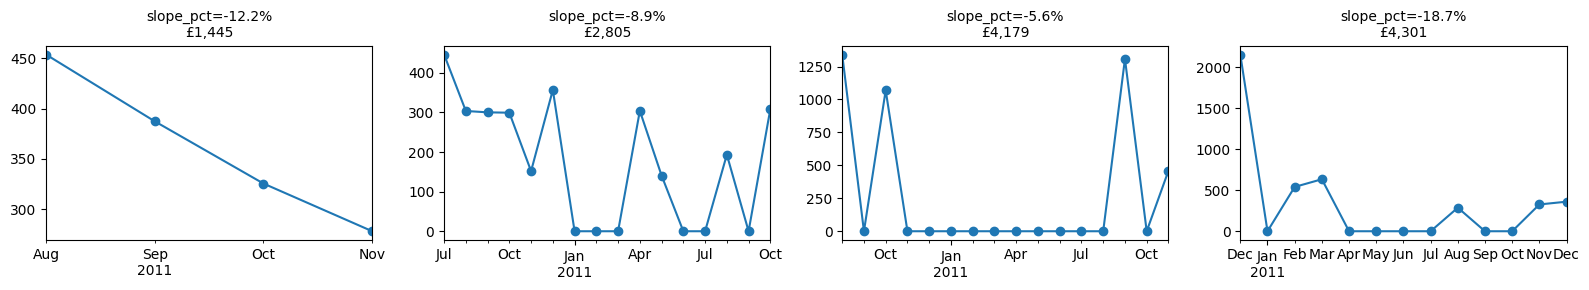

In [48]:
import matplotlib.pyplot as plt

# Pull 4 random declining Champions and plot their monthly trajectories
sample = declining_champs.sample(4, random_state=42)
fig, axes = plt.subplots(1, 4, figsize=(16, 3))

for ax, (_, row) in zip(axes, sample.iterrows()):
    monthly = (df[df['CustomerHashID']==row['CustomerHashID']]
                .set_index('InvoiceDateMin')['TotalPrice']
                .resample('ME').sum())
    monthly.plot(ax=ax, marker='o')
    ax.set_title(f"slope_pct={row['rev_slope_pct']*100:.1f}%\n£{row['total_revenue']:,.0f}", 
                 fontsize=10)
    ax.set_xlabel('')

plt.tight_layout()
plt.show()

**Okay there are a few things going on above from left 1 to right 4**
- 1 does look like a lower spend champion who we need to look after, outreach recommended
- 2 this looks a bit erratic, they seem to order in bursts, there might be some seasonality in here with oct - dec winter with what looks like the beginning of a repeat next oct and a mar to may spring-time, looks fine
- 3 this has an oct to oct pattern like yearly purchase, we would leave alone
- 4 one big purchase and then smaller purchases, looks like onboarding spike then stabilisation of lower purchases.

We definitely need to run the seasonality trends and then revisit this but also the above looks fine for now and we can extrapolate more from it with the K-means (behaviour based) testing and product affinities later.

---
---
# Seasonality

In [49]:
# Tag each line with quarter
df['order_quarter'] = df['InvoiceDateMin'].dt.quarter

# Revenue per customer per quarter
qrev = (df.groupby(['CustomerHashID','order_quarter'])['TotalPrice']
          .sum()
          .reset_index(name='quarter_rev'))

# Customer total
total = df.groupby('CustomerHashID')['TotalPrice'].sum().rename('cust_total').reset_index()

qrev = qrev.merge(total, on='CustomerHashID')
qrev['quarter_share'] = qrev['quarter_rev'] / qrev['cust_total']

# Each customer's top-quarter share
top_quarter_share = (qrev.groupby('CustomerHashID')['quarter_share']
                          .max()
                          .rename('top_quarter_share'))

# And which quarter that was — useful for naming personas later
top_quarter = (qrev.sort_values('quarter_share', ascending=False)
                    .drop_duplicates('CustomerHashID')
                    .set_index('CustomerHashID')['order_quarter']
                    .rename('peak_quarter'))

customer = customer.drop(columns=['top_quarter_share','peak_quarter'], errors='ignore')
customer = customer.merge(top_quarter_share, on='CustomerHashID', how='left')
customer = customer.merge(top_quarter,       on='CustomerHashID', how='left')

In [50]:
customer['is_seasonal'] = customer['top_quarter_share'] > 0.60

# Distribution check
print(customer['top_quarter_share'].describe())
print(customer['is_seasonal'].mean())   # what % of base is highly seasonal?
print(customer.loc[customer['is_seasonal'], 'peak_quarter'].value_counts())

count    5849.000000
mean        0.715754
std         0.250423
min         0.253122
25%         0.499793
50%         0.677431
75%         1.000000
max         1.000000
Name: top_quarter_share, dtype: float64
0.590186356642161
peak_quarter
4    1668
3     663
2     589
1     532
Name: count, dtype: int64


---
---
---
---
---
---
---
---
---
---